<a href="https://colab.research.google.com/github/sunnychen0610/git-tutorial/blob/main/Pandas.ipynb" target="_parent"><img src="https://colab.research.google.com/assets/colab-badge.svg" alt="Open In Colab"/></a>

In [1]:
import pandas as pd

# 準備一組 YouBike 站點的假資料 (字典 → DataFrame)
data = {
    "站名":   ["大安站", "信義站", "中山站", "松山站", "大安森林", "市府站", "南港站", "內湖站"],
    "行政區": ["大安區", "信義區", "中山區", "松山區", "大安區", "信義區", "南港區", "內湖區"],
    "可借":   [12, 0, 8, 5, 20, 3, 0, 15],
    "可還":   [8, 20, 12, 15, 0, 17, 25, 5],
    "總停車格": [20, 20, 20, 20, 20, 20, 25, 20],
}

df = pd.DataFrame(data)
df

,站名,行政區,可借,可還,總停車格
0,大安站,大安區,12,8,20
1,信義站,信義區,0,20,20
2,中山站,中山區,8,12,20
3,松山站,松山區,5,15,20
4,大安森林,大安區,20,0,20
5,市府站,信義區,3,17,20
6,南港站,南港區,0,25,25
7,內湖站,內湖區,15,5,20


In [2]:
# 看資料的常用指令
print("前 3 列：")
print(df.head())          # 看前幾列 (預設 5)

print("\n這張表有幾列幾欄:", df.shape)   # (列數, 欄數)

print("\n所有欄位名稱:", list(df.columns))

df.describe()

前 3 列：
     站名  行政區  可借  可還  總停車格
0   大安站  大安區  12   8    20
1   信義站  信義區   0  20    20
2   中山站  中山區   8  12    20
3   松山站  松山區   5  15    20
4  大安森林  大安區  20   0    20

這張表有幾列幾欄: (8, 5)

所有欄位名稱: ['站名', '行政區', '可借', '可還', '總停車格']


,可借,可還,總停車格
count,8.000000,8.00000,8.000000
mean,7.875000,12.75000,20.625000
std,7.278883,8.20714,1.767767
min,0.000000,0.00000,20.000000
25%,2.250000,7.25000,20.000000
50%,6.500000,13.50000,20.000000
75%,12.750000,17.75000,20.000000
max,20.000000,25.00000,25.000000


In [3]:
# (1) 挑「單一欄位」→ 用中括號 + 欄名
print("所有站名：")
print(df["站名"])

# (2) 挑「多個欄位」→ 中括號裡放一個清單
df[["站名", "可還"]]

# (3) 挑「符合條件的列」→ 在中括號裡放條件 (這叫布林篩選)
# 例如：找出「目前沒車可借」的站點
df[df["可還"] > 5]

# 用 & (且) 和 | (或) 串多個條件，每個條件要用小括號括起來
# 例如：大安區「而且」可借大於 10
df[(df["行政區"] == "松山區") & (df["可借"] > 2)]

所有站名：
0     大安站
1     信義站
2     中山站
3     松山站
4    大安森林
5     市府站
6     南港站
7     內湖站
Name: 站名, dtype: object


,站名,行政區,可借,可還,總停車格
3,松山站,松山區,5,15,20


In [4]:
# (1) 排序：依「可借」數量由多到少
df.sort_values("可借", ascending=False)

# (2) 分組統計 groupby：每個行政區的可借車輛「總和」
# 意思是：先按行政區分堆，再把每堆的「可借」加起來
df.groupby("行政區")["可借"].sum()

# groupby 也可以算平均、數量等
print("各行政區的平均可借車輛：")
print(df.groupby("行政區")["可借"].mean())

print("\n各行政區有幾個站：")
print(df.groupby("行政區")["站名"].count())

# (3) 新增欄位：用現有欄位算出新的
# 例如算「使用率」= 可還 / 總停車格 (車位被停走的比例)
df["使用率"] = df["可還"] / df["總停車格"]
df[["站名", "可還", "總停車格", "使用率"]]

各行政區的平均可借車輛：
行政區
中山區     8.0
信義區     1.5
內湖區    15.0
南港區     0.0
大安區    16.0
松山區     5.0
Name: 可借, dtype: float64

各行政區有幾個站：
行政區
中山區    1
信義區    2
內湖區    1
南港區    1
大安區    2
松山區    1
Name: 站名, dtype: int64


,站名,可還,總停車格,使用率
0,大安站,8,20,0.40
1,信義站,20,20,1.00
2,中山站,12,20,0.60
3,松山站,15,20,0.75
4,大安森林,0,20,0.00
5,市府站,17,20,0.85
6,南港站,25,25,1.00
7,內湖站,5,20,0.25


In [5]:
import matplotlib.pyplot as plt
import matplotlib.font_manager as fm
import os
import urllib.request

# 下載 Google 的思源黑體 (Noto Sans TC)，存到本機
font_url = "https://github.com/googlefonts/noto-cjk/raw/main/Sans/OTF/TraditionalChinese/NotoSansCJKtc-Regular.otf"
font_path = "/content/NotoSansCJKtc-Regular.otf"

if not os.path.exists(font_path):
    print("下載中文字型中…")
    urllib.request.urlretrieve(font_url, font_path)
    print("下載完成！")

# 把字型註冊給 matplotlib
fm.fontManager.addfont(font_path)
plt.rcParams["font.family"] = "Noto Sans CJK TC"
plt.rcParams["axes.unicode_minus"] = False   # 讓負號正常顯示

下載中文字型中…
下載完成！


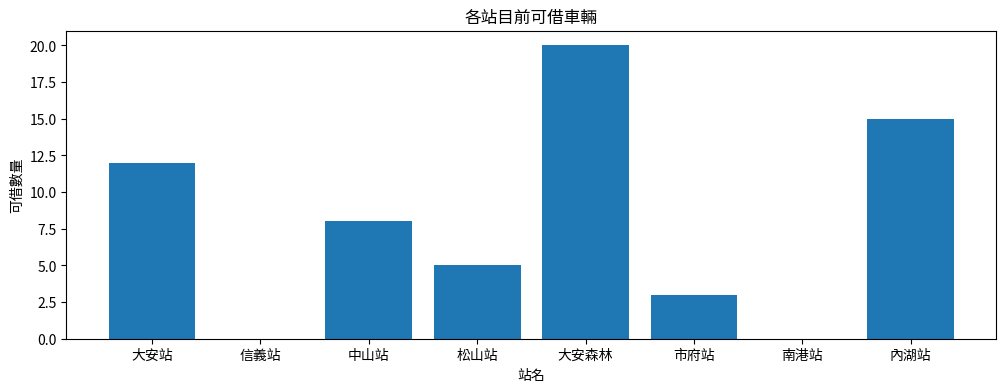

In [6]:
# (1) 長條圖 bar：各站可借車輛
plt.figure(figsize=(12, 4))
plt.bar(df["站名"], df["可借"])
plt.title("各站目前可借車輛")
plt.xlabel("站名")
plt.ylabel("可借數量")
plt.show()

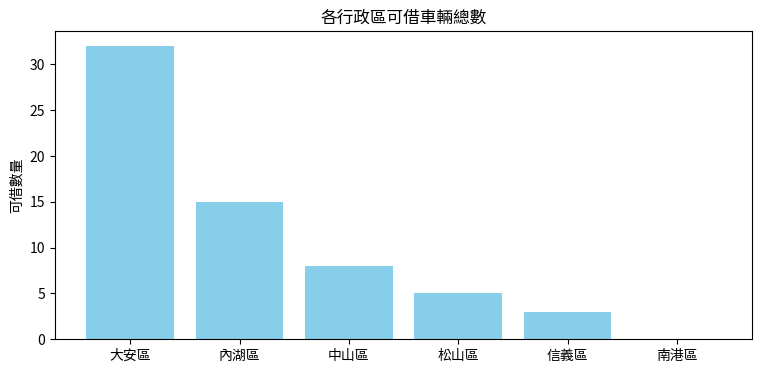

In [7]:
# 結合 pandas：各行政區可借總數，由多到少畫出來
by_area = df.groupby("行政區")["可借"].sum().sort_values(ascending=False)

plt.figure(figsize=(9, 4))
plt.bar(by_area.index, by_area.values, color="skyblue")
plt.title("各行政區可借車輛總數")
plt.ylabel("可借數量")
plt.show()

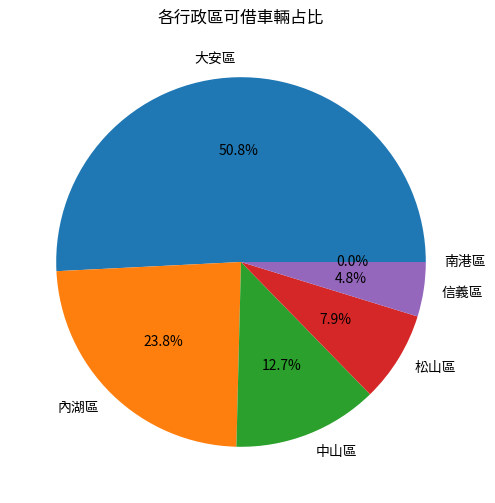

In [8]:
# (2) 圓餅圖 pie：各行政區可借車輛占比
plt.figure(figsize=(6, 6))
plt.pie(by_area.values, labels=by_area.index, autopct="%1.1f%%")
plt.title("各行政區可借車輛占比")
plt.show()

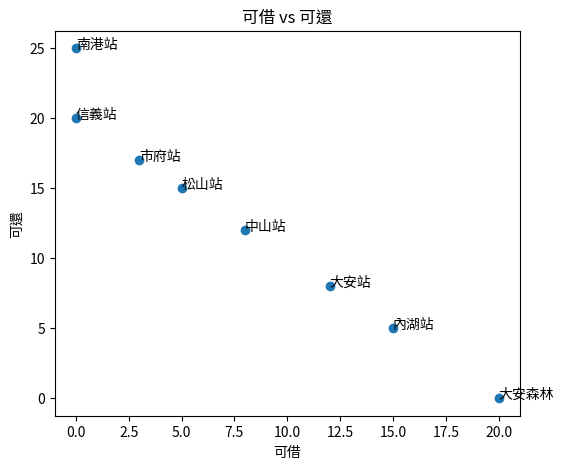

In [9]:
# (3) 散點圖 scatter：看「可借」和「可還」有沒有關係
plt.figure(figsize=(6, 5))
plt.scatter(df["可借"], df["可還"])
plt.title("可借 vs 可還")
plt.xlabel("可借")
plt.ylabel("可還")
# 幫每個點標上站名
for _, row in df.iterrows():
    plt.annotate(row["站名"], (row["可借"], row["可還"]))
plt.show()

In [10]:
import requests

URL = "https://tcgbusfs.blob.core.windows.net/dotapp/youbike/v2/youbike_immediate.json"

resp = requests.get(URL, timeout=10)
print("HTTP 狀態碼:", resp.status_code)     # 200 = 成功

records = resp.json()                        # JSON → Python 清單
print("總共幾個站點:", len(records))

HTTP 狀態碼: 200
總共幾個站點: 1774


In [11]:
import pandas as pd

df = pd.DataFrame(records)

# 把要用的數字欄位轉成數字型別
for col in ["available_rent_bikes", "available_return_bikes", "total"]:
    if col in df.columns:
        df[col] = pd.to_numeric(df[col], errors="coerce")

# 只看幾個重要欄位
df[["sna", "sarea", "available_rent_bikes", "available_return_bikes"]].head(20)

,sna,sarea,available_rent_bikes,available_return_bikes
0,YouBike2.0_捷運科技大樓站,大安區,4,23
1,YouBike2.0_復興南路二段273號前,大安區,5,16
2,YouBike2.0_國北教大實小東側門,大安區,0,28
3,YouBike2.0_和平公園東側,大安區,10,1
4,YouBike2.0_辛亥復興路口西北側,大安區,12,3
5,YouBike2.0_復興南路二段280號前,大安區,10,17
6,YouBike2.0_復興南路二段340巷口,大安區,10,0
7,YouBike2.0_新生南路三段52號前,大安區,0,17
8,YouBike2.0_新生南路三段66號前,大安區,12,3
9,YouBike2.0_新生南路三段82號前,大安區,7,13


In [12]:
by_area = df.groupby("sarea")["available_rent_bikes"].sum().sort_values(ascending=False)
print(by_area)

sarea
大安區       2075
中山區       2067
內湖區       1847
中正區       1591
士林區       1528
信義區       1348
北投區       1310
南港區       1051
文山區       1041
萬華區       1035
大同區        830
松山區        817
臺大公館校區     645
Name: available_rent_bikes, dtype: int64


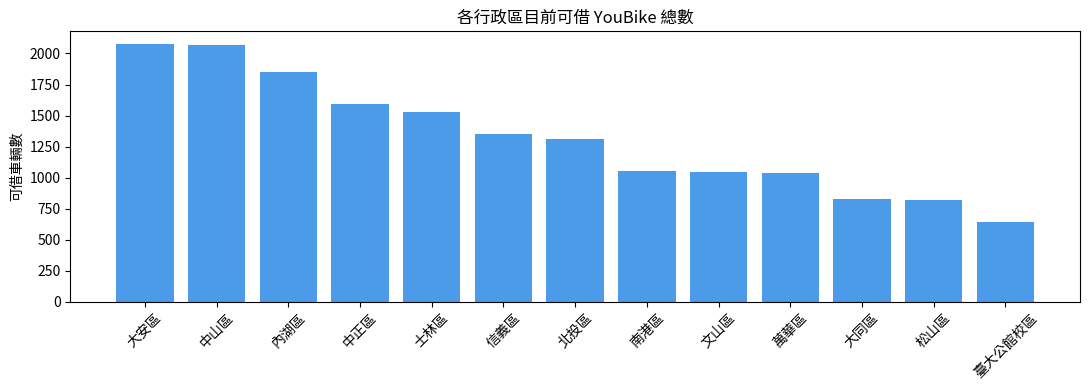

In [13]:
# 畫成長條圖
plt.figure(figsize=(11, 4))
plt.bar(by_area.index, by_area.values, color="#4C9BE8")
plt.title("各行政區目前可借 YouBike 總數")
plt.ylabel("可借車輛數")
plt.xticks(rotation=45)
plt.tight_layout()
plt.show()

In [14]:
# 找出目前「沒車可借」的站點 (可借 = 0) → 這就是產品可以解決的問題
empty = df[df["available_rent_bikes"] == 0]
print(f"目前完全沒車可借的站點：{len(empty)} 個 (共 {len(df)} 站)\n")
print(empty[["sna", "sarea"]].head(10).to_string(index=False))

目前完全沒車可借的站點：117 個 (共 1774 站)

                     sna sarea
    YouBike2.0_國北教大實小東側門   大安區
   YouBike2.0_新生南路三段52號前   大安區
  YouBike2.0_羅斯福路三段245號前   大安區
        YouBike2.0_溫州停車場   大安區
       YouBike2.0_臺大男一舍前   大安區
       YouBike2.0_辛亥泰順街口   大安區
  YouBike2.0_捷運古亭站(5號出口)   大安區
  YouBike2.0_捷運東門站(3號出口)   大安區
         YouBike2.0_金甌女中   大安區
YouBike2.0_敦化南路二段293巷口南側   大安區


In [15]:
def find_bikes(area, top=10):
    records = requests.get(URL, timeout=10).json()      # 每次抓最新資料
    d = pd.DataFrame(records)
    d["available_rent_bikes"] = pd.to_numeric(d["available_rent_bikes"], errors="coerce")

    result = d[d["sarea"] == area].sort_values("available_rent_bikes", ascending=False)
    if len(result) == 0:
        return f"找不到「{area}」，請確認行政區名稱 (例如：大安區)"

    lines = [f"📍 {area} 目前最多車可借的前 {top} 站："]
    for _, row in result.head(top).iterrows():
        lines.append(f"   {row['sna']}｜可借 {int(row['available_rent_bikes'])} 台")
    return "\n".join(lines)

# 試用看看 (換成任何行政區)
print(find_bikes("北投區"))

📍 北投區 目前最多車可借的前 10 站：
   YouBike2.0_好市多北投店｜可借 47 台
   YouBike2.0_關渡宮｜可借 44 台
   YouBike2.0_捷運復興崗站(1號出口)｜可借 41 台
   YouBike2.0_桃源國中｜可借 34 台
   YouBike2.0_立功立德路口｜可借 34 台
   YouBike2.0_捷運關渡站(1號出口)｜可借 31 台
   YouBike2.0_捷運北投站(1號出口)(北投路側)｜可借 27 台
   YouBike2.0_國防大學政治作戰學院｜可借 26 台
   YouBike2.0_捷運奇岩站(三合街)｜可借 25 台
   YouBike2.0_石牌立農街口｜可借 25 台


In [16]:
try:
    import ipywidgets as widgets
    from IPython.display import display

    areas = sorted(df["sarea"].dropna().unique().tolist())
    dd = widgets.Dropdown(options=areas, description="行政區:")
    out = widgets.Output()

    def on_change(ch):
        if ch["name"] == "value" and ch["type"] == "change":
            out.clear_output()
            with out:
                print(find_bikes(ch["new"]))

    dd.observe(on_change)
    display(dd, out)
    with out:
        print(find_bikes(dd.value))
except Exception:
    print(find_bikes("信義區"))

Dropdown(description='行政區:', options=('中山區', '中正區', '信義區', '內湖區', '北投區', '南港區', '士林區', '大同區', '大安區', '文山區', '松…

Output()